In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

In [2]:
def download(ticker, start=None, end=None):
    if start is None:
        return yf.Ticker(ticker).history(period="max")
    else:
        return yf.Ticker(ticker).history(start=start, end=end)

In [3]:
df = download('AAPL', start='2020-07-01', end='2020-12-31')
df['M15'] = df['Close'].rolling(15).mean() 
df['M50'] = df['Close'].rolling(50).mean() 

In [4]:
DATE = df.index[50:]
y = df['Close'].loc[DATE]
y_15 = df['M15'].loc[DATE]
y_50 = df['M50'].loc[DATE]

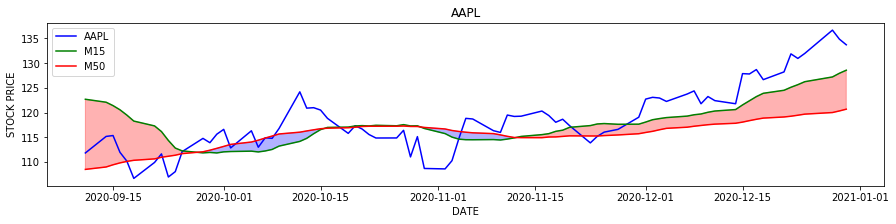

In [5]:
fig, ax = plt.subplots(figsize=(15, 3))

ax.plot(DATE, y, label='AAPL', color='b')
ax.plot(DATE, y_15, label='M15', color='g')
ax.plot(DATE, y_50, label='M50', color='r')

ax.fill_between(DATE, y_15, y_50, 
                where=(y_15 > y_50), interpolate=True, color='r', 
                alpha=0.3)
ax.fill_between(DATE, y_15, y_50, 
                where=(y_15 <= y_50), interpolate=True, color='b', 
                alpha=0.3)

ax.set_xlabel('DATE')
ax.set_ylabel('STOCK PRICE')
ax.set_title('AAPL')

ax.legend()